# Module 4 — Exploratory Data Analysis & Visualization

EDA is just a fancy phrase for **having a conversation with your data**. You ask a
question, you draw a chart, the chart answers, and you write down what it *means*.
That's it. Do this well and you can say something true and useful about a dataset
*before* any model exists — which is exactly what makes a portfolio project sound
insightful instead of robotic.

The habit we build here, over and over: **question → chart → interpretation.**
Every plot ends in one sentence of meaning, because a chart with no takeaway is
just decoration.

> 🧠 **Analogy** — EDA is like being a detective at a crime scene. You don't guess who did it immediately — you look for clues (patterns), follow leads (questions), and each clue narrows down the story before you name a suspect (build a model).

## 4.1 Load the clean data and set up our tools

> 🌱 **In plain English**
>
> We use two plotting libraries: **matplotlib** is the engine (it can draw anything),
> and **seaborn** sits on top of it to make good-looking statistical charts with one
> line. We load the *cleaned* file we saved in the last module — always explore clean
> data, not raw mess.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")   # clean, consistent look
plt.rcParams["figure.figsize"] = (7, 4)

df = pd.read_csv("../data/customers_clean.csv")   # the cleaned artifact
print("shape:", df.shape)
df.head()

shape: (500, 16)


,customer_id,age,income,city,plan,tenure_months,monthly_spend,support_calls,churn,signup_date,signup_year,signup_month,signup_weekday,days_as_member,income_was_missing,income_capped
0,1,38.0,5000000.00,Kisumu,Basic,14,186.65,1,0,2023-09-13,2023,9,Wednesday,110,0,109551.2875
1,2,25.0,76695.05,Nakuru,Basic,46,76.83,1,0,2023-04-10,2023,4,Monday,266,0,76695.0500
2,3,35.0,34209.54,Nairobi,Basic,29,37.36,1,1,2023-01-09,2023,1,Monday,357,0,34209.5400
3,4,44.0,23126.82,Mombasa,Premium,25,23.34,0,0,2022-07-16,2022,7,Saturday,534,0,23126.8200
4,5,18.0,11133.74,Nairobi,Basic,50,12.17,4,1,2022-08-13,2022,8,Saturday,506,0,11133.7400


> 🔤 **Reading the code (line by line)**
>
> - `import matplotlib.pyplot as plt` / `import seaborn as sns` → load the plotting
>   tools under their standard nicknames.
> - `sns.set_theme(style="whitegrid")` → apply a tidy default style to every chart.
> - `plt.rcParams["figure.figsize"] = (7, 4)` → default chart size (width, height).
> - `pd.read_csv(...)` → load the cleaned dataset; `.head()` shows the first 5 rows.

> 📖 **matplotlib** = Python's core plotting engine — powerful, draws anything

> 📖 **seaborn** = a library built on matplotlib for quick, pretty statistical charts

## 4.2 The EDA framework (memorize this)

> 🌱 **In plain English**
>
> Don't plot randomly. Follow a ladder, from simple to complex:
> 1. **Shape & types** — how big is it, what columns exist.
> 2. **Univariate** — one variable at a time: what's its typical value and spread?
> 3. **Bivariate** — two variables: how do they relate?
> 4. **Target-focused** — how does each feature relate to what we want to predict
>    (here, `churn` = did the customer leave)?
> 5. **Multivariate** — many variables together (correlations, interactions).
>
> At every step, narrate: *what do I see, and so what?*

> 📖 **univariate** = looking at ONE variable on its own

> 📖 **bivariate** = looking at the relationship between TWO variables

> 📖 **churn** = when a customer stops using / cancels a service — the thing we'll predict

## 4.3 Univariate — numeric distributions (histogram)

> 🌱 **In plain English**
>
> A **histogram** chops a numeric column into bins and counts how many values fall in
> each — the shape shows you where values pile up, how spread out they are, and
> whether they're lopsided (**skewed**). We already suspect income is skewed; let's
> see it.

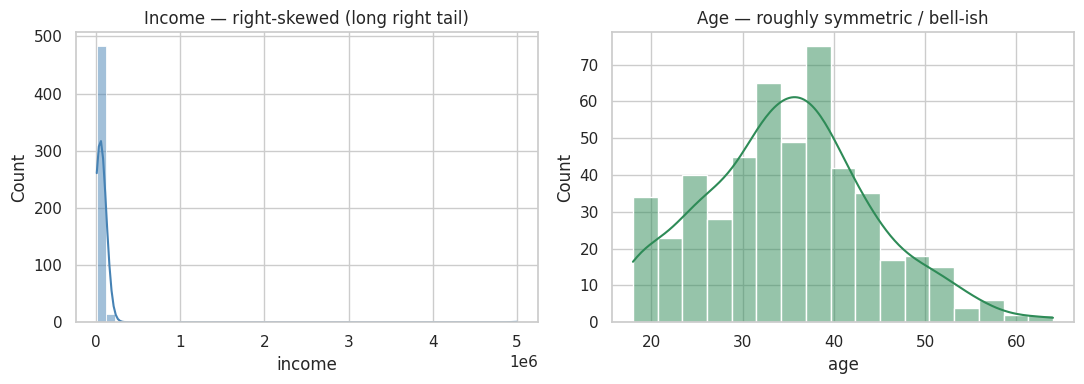

income skew: 21.84 | age skew: 0.25


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["income"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Income — right-skewed (long right tail)")
sns.histplot(df["age"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Age — roughly symmetric / bell-ish")
plt.tight_layout()
plt.show()

print("income skew:", round(df["income"].skew(), 2),
      "| age skew:", round(df["age"].skew(), 2))

> 🔤 **Reading the code (line by line)**
>
> - `plt.subplots(1, 2)` → make a row of 2 charts side by side; `axes[0]`, `axes[1]`
>   are the left and right panels.
> - `sns.histplot(col, kde=True, ax=...)` → draw a histogram; `kde=True` overlays a
>   smooth curve of the distribution shape.
> - `.set_title(...)` → label each panel.
> - `df["income"].skew()` → a number: 0 = symmetric, positive = long right tail.

> 🎓 **Go deeper**
>
> Income's positive skew (>0) means a few high earners stretch the right tail, which
> drags the *mean* above the *median*. This is exactly why we imputed income with the
> median (robust) in cleaning, and why we'll consider a **log transform** later in
> Feature Engineering — logs squash long tails toward symmetry.

> 📖 **histogram** = a bar chart of counts per value-range (bin) — shows a distribution's shape

> 📖 **skew** = lopsidedness of a distribution; positive = long right tail

> 📖 **KDE** = Kernel Density Estimate — a smooth curve approximating the distribution

## 4.4 Univariate — the boxplot (spread + outliers at a glance)

> 🌱 **In plain English**
>
> A **boxplot** is the fastest way to see spread and spot outliers. The line in the
> box is the median, the box itself is the middle 50% of the data (the IQR), the
> whiskers show the typical range, and any dots beyond are flagged as outliers.

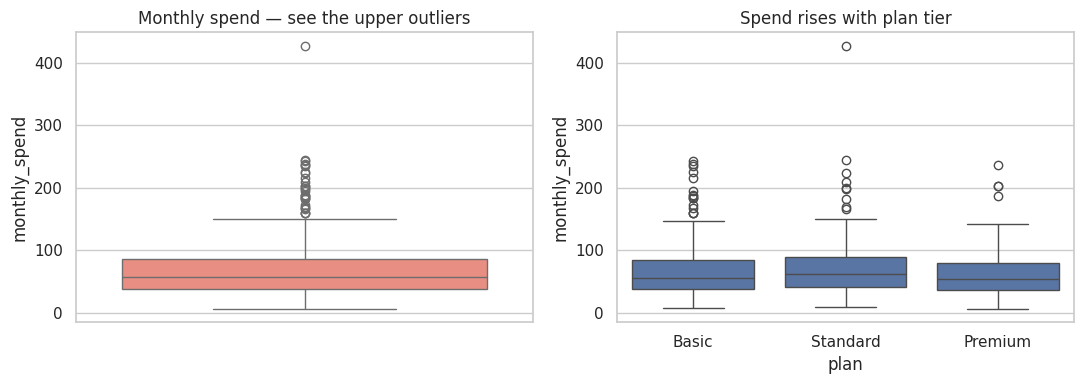

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df["monthly_spend"], ax=ax[0], color="salmon")
ax[0].set_title("Monthly spend — see the upper outliers")
sns.boxplot(x="plan", y="monthly_spend", data=df, ax=ax[1],
            order=["Basic", "Standard", "Premium"])
ax[1].set_title("Spend rises with plan tier")
plt.tight_layout()
plt.show()

> 🔤 **Reading the code (line by line)**
>
> - `sns.boxplot(y=col)` → a single boxplot of one numeric column.
> - `sns.boxplot(x="plan", y="monthly_spend", data=df, order=[...])` → one box PER
>   plan category, in the order we specify — great for comparing groups.

> 🎓 **Go deeper**
>
> The box climbing from Basic → Premium confirms higher tiers spend more — a sanity
> check that the data behaves sensibly. Boxplots-split-by-category are one of the most
> useful EDA charts you'll ever draw: they compare a numeric outcome across groups in
> a single glance.

> 📖 **boxplot** = a chart showing median, middle-50% box (IQR), whiskers, and outlier dots

## 4.5 Categorical distributions — counts & rates

> 🌱 **In plain English**
>
> For category columns (like city or plan) we count how many rows fall in each, and —
> more interestingly — compute a **rate** per category (like the churn rate per plan).
> Rates are where the business insights hide.

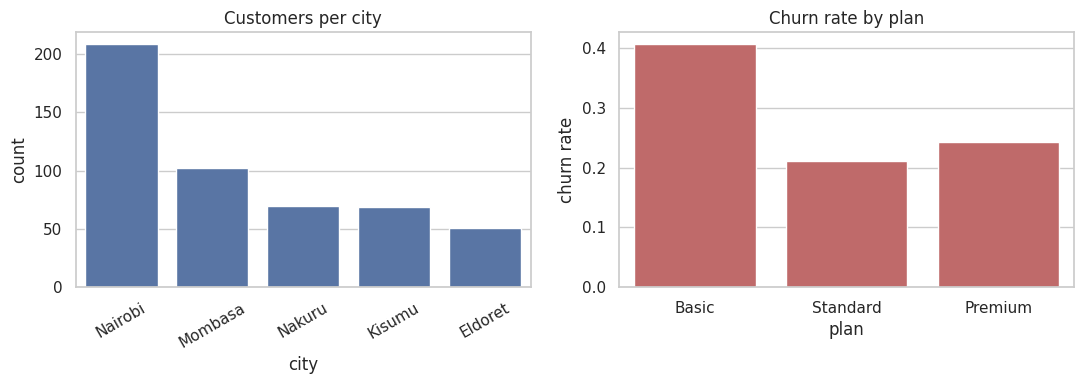

plan
Basic       0.406
Standard    0.212
Premium     0.242
Name: churn, dtype: float64


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="city", data=df, ax=ax[0],
              order=df["city"].value_counts().index)
ax[0].set_title("Customers per city")
ax[0].tick_params(axis="x", rotation=30)

churn_rate = df.groupby("plan", observed=True)["churn"].mean() \
               .reindex(["Basic", "Standard", "Premium"])
sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=ax[1], color="indianred")
ax[1].set_title("Churn rate by plan")
ax[1].set_ylabel("churn rate")
plt.tight_layout()
plt.show()
print(churn_rate.round(3))

> 🔤 **Reading the code (line by line)**
>
> - `sns.countplot(x="city")` → bar chart of how many rows per city; `order=...value_counts().index`
>   sorts bars tallest-first.
> - `tick_params(rotation=30)` → tilt the city labels so they don't overlap.
> - `df.groupby("plan")["churn"].mean()` → since churn is 0/1, the mean IS the churn
>   RATE per plan. `.reindex([...])` puts the plans in a sensible order.
> - `sns.barplot(...)` → draw those rates as bars.

> 🎓 **Go deeper**
>
> If Basic churns most, that's an actionable business insight — retention effort
> should target Basic customers. THIS is the kind of sentence that turns a chart into
> value, and it's what an interviewer wants to hear: not "I made a bar chart" but
> "the chart told me where the money is leaking."

> 🗣️ **Say this in an interview** — "For categorical features I don't just count — I compute the target rate per category, because that's what surfaces where to act."

## 4.6 Bivariate — scatter plots (numeric vs numeric)

> 🌱 **In plain English**
>
> A **scatter plot** puts one number on the x-axis, another on the y-axis, and a dot
> per row. It reveals relationships — do the dots trend up, down, or cluster? We color
> the dots by churn to see *where* churners live in the picture.

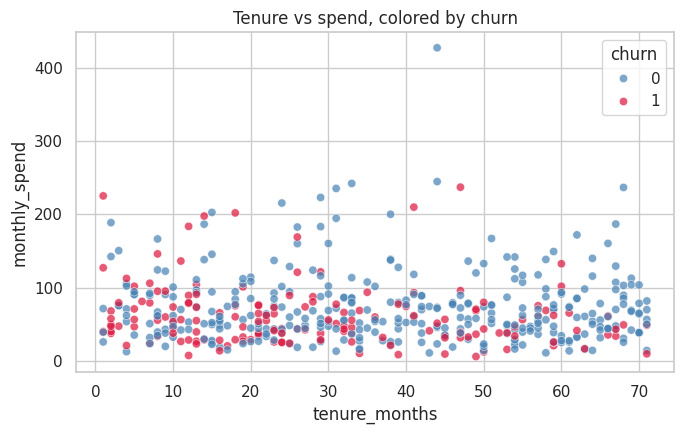

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(data=df, x="tenure_months", y="monthly_spend",
                hue="churn", alpha=0.7, palette={0: "steelblue", 1: "crimson"})
ax.set_title("Tenure vs spend, colored by churn")
plt.tight_layout()
plt.show()

> 🔤 **Reading the code (line by line)**
>
> - `sns.scatterplot(data=df, x=..., y=..., hue="churn")` → dots colored by churn.
> - `alpha=0.7` → slight transparency so overlapping dots are visible.
> - `palette={0: "steelblue", 1: "crimson"}` → blue = stayed, red = churned.

> 🎓 **Go deeper**
>
> Look at where the red (churned) dots cluster. If churn concentrates at *low tenure*,
> tenure is a strong predictor — which matches how the data was designed. You're now
> *reading* the signal a model will later exploit, by eye, before writing any ML.

> 📖 **scatter plot** = dots plotting two numeric variables against each other to show their relationship

## 4.7 Multivariate — the correlation heatmap

> 🌱 **In plain English**
>
> **Correlation** is a single number from -1 to +1 that measures how strongly two
> numeric columns move together in a straight-line way: +1 = perfectly up together,
> -1 = perfectly opposite, 0 = no linear link. A **heatmap** colors all the pairs at
> once so you can scan the whole dataset in one image.

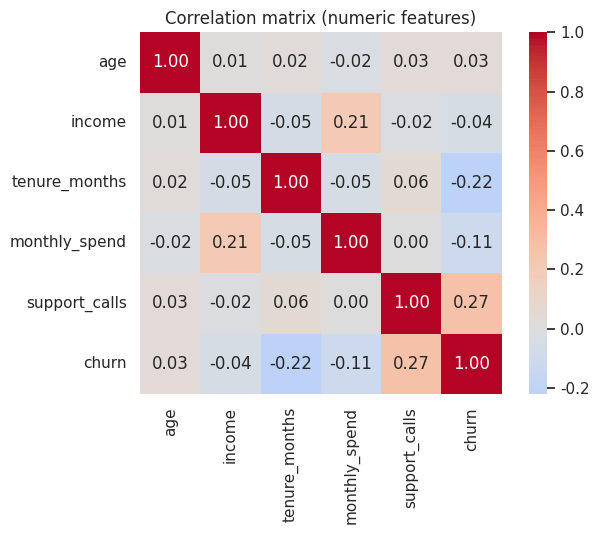

In [6]:
num_cols = ["age", "income", "tenure_months", "monthly_spend",
            "support_calls", "churn"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

> 🔤 **Reading the code (line by line)**
>
> - `df[num_cols].corr()` → compute correlation for every pair of numeric columns.
> - `sns.heatmap(corr, annot=True, fmt=".2f")` → color grid with the numbers printed
>   to 2 decimals; `cmap="coolwarm", center=0` → blue negative, red positive, white ~0.

> 🎓 **Go deeper**
>
> Read the `churn` row: the SIGN gives direction, the MAGNITUDE gives strength. Expect
> `support_calls` positive (more calls → more churn) and `tenure_months` negative
> (longer tenure → less churn). If two *features* are very highly correlated with each
> OTHER, that's **multicollinearity** — a heads-up for linear models later.

> ⚠️ **Watch out** — Correlation is LINEAR only (it can miss curved relationships), and correlation is NOT causation. Always say both out loud when presenting a heatmap.

> 📖 **correlation** = a number in [-1, 1] measuring linear association between two variables

> 📖 **multicollinearity** = when two+ features are strongly correlated with each other, destabilizing linear models

## 4.8 The pairplot — a fast multi-view

> 🌱 **In plain English**
>
> A **pairplot** draws a small scatter for every pair of a handful of columns, plus
> each column's distribution on the diagonal. Use it on a FEW columns to eyeball many
> relationships at once. (Don't throw 30 columns at it — it'll be unreadable.)

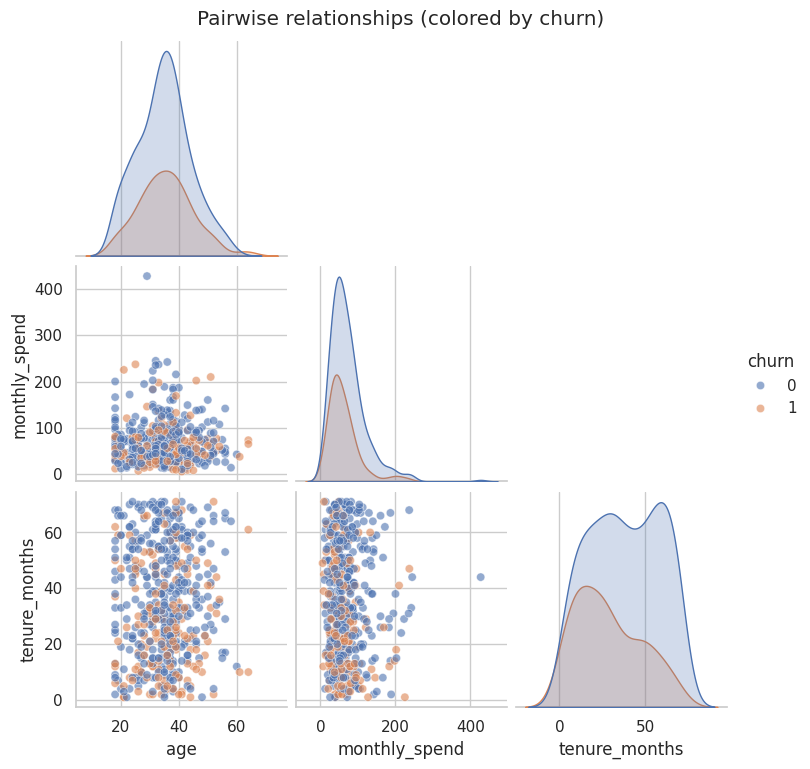

In [7]:
sns.pairplot(df[["age", "monthly_spend", "tenure_months", "churn"]],
             hue="churn", corner=True, plot_kws={"alpha": 0.6})
plt.suptitle("Pairwise relationships (colored by churn)", y=1.02)
plt.show()

> 🔤 **Reading the code (line by line)**
>
> - `sns.pairplot(df[[...]], hue="churn", corner=True)` → grid of scatters for each
>   pair, colored by churn; `corner=True` shows only the lower triangle (no repeats).

## 4.9 Principles of an honest chart (interview-worthy)

> 🌱 **In plain English**
>
> Charts can mislead — accidentally or on purpose. A professional makes honest ones:

- **Label everything**: title, axes, units. An unlabeled axis is a red flag.
- **Pick the right chart**: distribution → hist/box; relationship → scatter;
  category comparison → bar; part-of-whole → (sparingly) bar, not pie.
- **Don't distort**: avoid truncated y-axes that exaggerate tiny differences.
- **One message per chart**: if it needs a paragraph to explain, split it.
- **End with a takeaway**: "so what?" beats "here's a plot".

> 🗣️ **Say this in an interview** — "Every chart I ship has labeled axes, one message, an honest scale, and a one-line takeaway. A plot without a 'so what' is decoration, not analysis."

## 4.10 Try it yourself

> ✍️ **Try this yourself** — 1. Plot income BEFORE vs AFTER a `log1p` transform (below). Which looks more
   symmetric? (This foreshadows Feature Engineering.)
2. Make a boxplot of `monthly_spend` split by `churn`. Do churners spend differently?
3. Build a churn-rate bar chart by `city`. Is any city notably worse?
4. Write three insight sentences you could put on a portfolio project page.

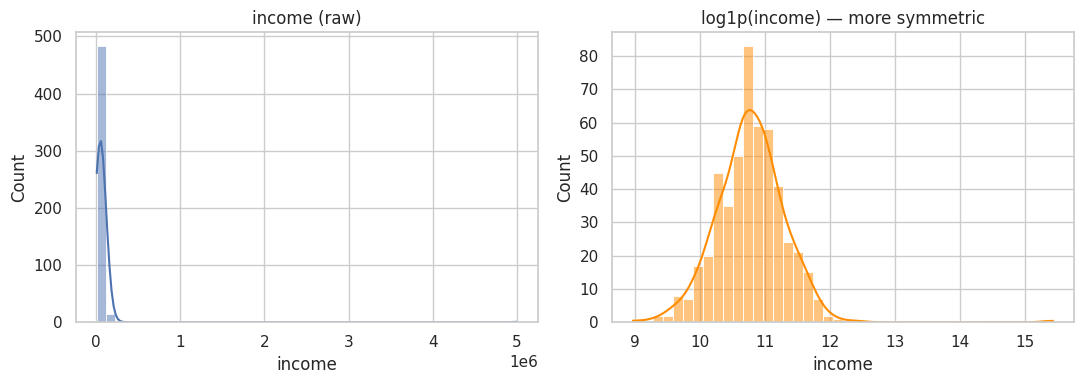

skew raw: 21.84 | skew log: 1.16


In [8]:
# Scratch: log transform preview
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["income"], kde=True, ax=ax[0]); ax[0].set_title("income (raw)")
sns.histplot(np.log1p(df["income"]), kde=True, ax=ax[1], color="darkorange")
ax[1].set_title("log1p(income) — more symmetric")
plt.tight_layout(); plt.show()
print("skew raw:", round(df['income'].skew(),2),
      "| skew log:", round(np.log1p(df['income']).skew(),2))

> 🔤 **Reading the code (line by line)**
>
> - `np.log1p(x)` → computes log(1 + x); the "+1" safely handles zeros. It compresses
>   large values more than small ones, pulling in a long right tail.
> - Compare the two skew numbers: the log version should be much closer to 0.

## Summary

- EDA = **question → chart → interpretation**, always ending in a takeaway.
- **Univariate**: histogram (shape/skew), boxplot (spread/outliers).
- **Bivariate**: scatter (num–num), box/bar (cat–num), grouped rates.
- **Multivariate**: correlation heatmap (linear only; ≠ causation), pairplot.
- Charts must be **labeled, honest, and single-message**.

Next: **Statistics & Probability**, the reasoning behind the charts.